In [1]:
import torch
import torch.nn as nn

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
## Load the discriminator model

discriminator = nn.Sequential(
    nn.Conv2d(1, 64, (3,3), (2,2), padding=1), ## 14 x 14
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.02),
    nn.Conv2d(64, 64, (3,3), (2,2), padding=1), ## 7 x 7
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.02),

    nn.Flatten(),
    nn.Linear(3136, 1),
    nn.Sigmoid()
).to(device)

discriminator.load_state_dict(torch.load('/u/zup7mn/Classes/NN/digit4/src/models/discriminator_last.pth'))
discriminator.eval()

X = torch.randn(16, 1, 28, 28).to(device)
score = discriminator(X)
print(score)


tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], device='cuda:0', grad_fn=<SigmoidBackward0>)


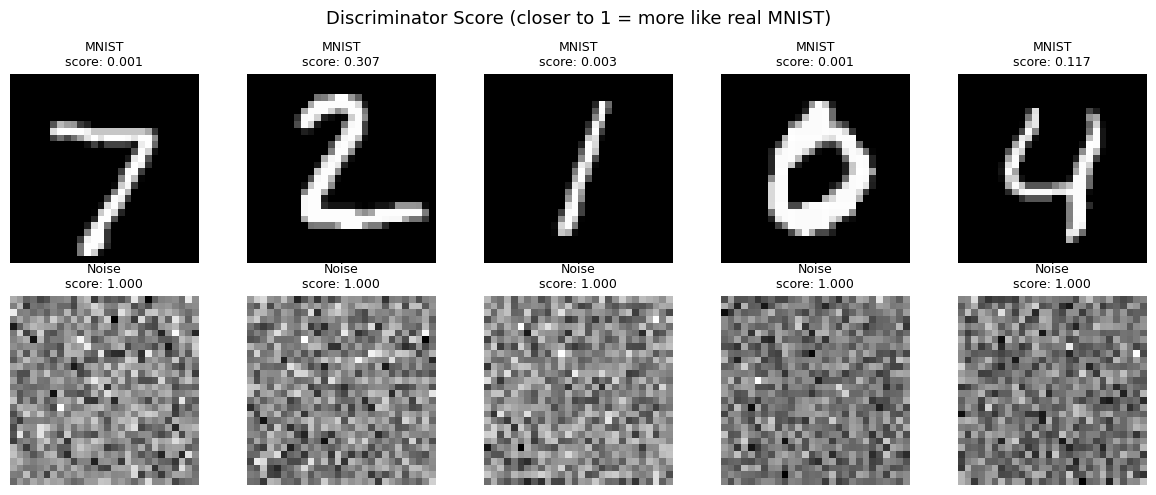

In [2]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

# Load 5 MNIST images
mnist = torchvision.datasets.MNIST(root='/tmp/mnist', train=False, download=True,
                                    transform=transforms.ToTensor())
mnist_images = torch.stack([mnist[i][0] for i in range(5)]).to(device)  # (5,1,28,28)

# 5 random noise images
noise_images = torch.randn(5, 1, 28, 28).to(device)

# Discriminator scores
with torch.no_grad():
    mnist_scores = discriminator(mnist_images).squeeze().cpu().numpy()
    noise_scores = discriminator(noise_images).squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Discriminator Score (closer to 1 = more like real MNIST)', fontsize=13)

for i in range(5):
    ax = axes[0, i]
    ax.imshow(mnist_images[i, 0].cpu().numpy(), cmap='gray')
    ax.set_title(f'MNIST\nscore: {mnist_scores[i]:.3f}', fontsize=9)
    ax.axis('off')

for i in range(5):
    ax = axes[1, i]
    ax.imshow(noise_images[i, 0].cpu().numpy(), cmap='gray')
    ax.set_title(f'Noise\nscore: {noise_scores[i]:.3f}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [3]:
digit_classifier = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=5, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.ReLU(),
    nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(64 * 676, 10),
    #nn.Softmax(dim=1)
).to(device)


In [4]:
CLASSIFIER_PATH = "/u/zup7mn/Classes/NN/digit4/src/mnist_classifier/mnist_mixup_classifier.pth"
digit_classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=device))
digit_classifier.eval()

Sequential(
  (0): Conv2d(1, 128, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (1): Dropout(p=0.2, inplace=False)
  (2): ReLU()
  (3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): Dropout(p=0.2, inplace=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=43264, out_features=10, bias=True)
)

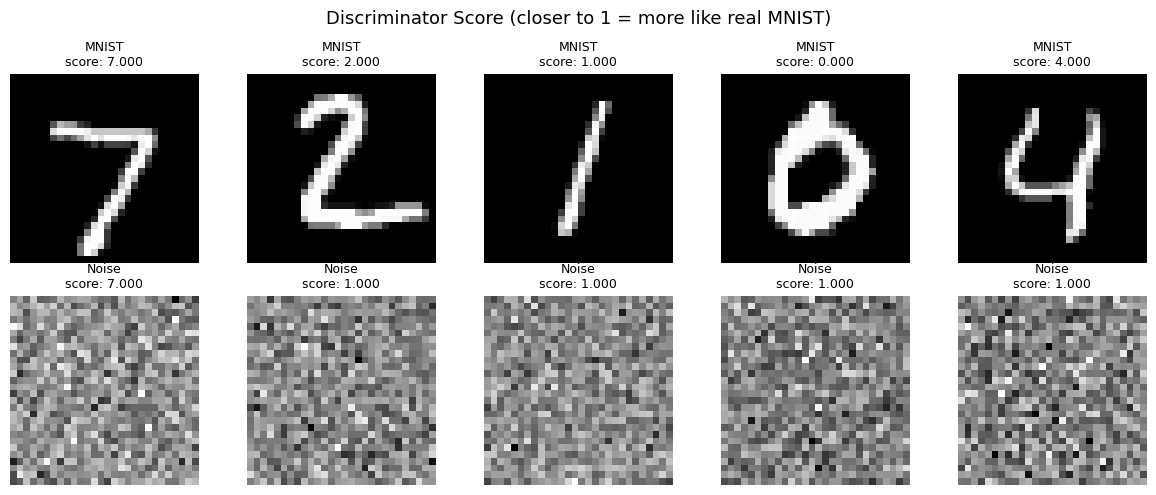

In [5]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

# Load 5 MNIST images
mnist = torchvision.datasets.MNIST(root='/tmp/mnist', train=False, download=True,
                                    transform=transforms.ToTensor())
mnist_images = torch.stack([mnist[i][0] for i in range(5)]).to(device)  # (5,1,28,28)

# 5 random noise images
noise_images = torch.randn(5, 1, 28, 28).to(device)

# Discriminator scores
with torch.no_grad():
    mnist_classes = nn.Softmax(dim=1)(digit_classifier(mnist_images)).squeeze().cpu().numpy().argmax(axis=1)
    noise_classes = nn.Softmax(dim=1)(digit_classifier(noise_images)).squeeze().cpu().numpy().argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Discriminator Score (closer to 1 = more like real MNIST)', fontsize=13)

for i in range(5):
    ax = axes[0, i]
    ax.imshow(mnist_images[i, 0].cpu().numpy(), cmap='gray')
    ax.set_title(f'MNIST\nscore: {mnist_classes[i]:.3f}', fontsize=9)
    ax.axis('off')

for i in range(5):
    ax = axes[1, i]
    ax.imshow(noise_images[i, 0].cpu().numpy(), cmap='gray')
    ax.set_title(f'Noise\nscore: {noise_classes[i]:.3f}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [6]:
from score_functions import novelty

In [7]:
import importlib
import score_functions
importlib.reload(score_functions)
from score_functions import novelty

# Get some 2s and 6s from the MNIST dataset loaded previously
twos = [mnist[i][0] for i in range(len(mnist)) if mnist[i][1] == 2][:5]
sixes = [mnist[i][0] for i in range(len(mnist)) if mnist[i][1] == 6][:5]

twos_tensor = torch.stack(twos).to(device)
sixes_tensor = torch.stack(sixes).to(device)

# Create 5 images of 2s and 6s overlayed together
overlayed = torch.clamp(twos_tensor + sixes_tensor, 0, 1)

# 5 noise images
noise_images = torch.randn(5, 1, 28, 28).to(device)

print("Novelty on noise images:")
print(novelty(noise_images))

print("Novelty on overlayed 2s and 6s:")
print(novelty(overlayed))

Novelty on noise images:
[0.000000e+00 7.707142e-44 0.000000e+00 0.000000e+00 3.785882e-39]
Novelty on overlayed 2s and 6s:
[0.00618775 0.1174412  0.0022406  0.00351965 0.0024387 ]
